# Phenology Intelligence - Anomaly Validation Notebook

## Purpose

This notebook provides scientific validation, visual diagnostics, and ecological sanity checking for the phenology intelligence project. It reads existing outputs from the processing pipeline and generates interactive diagnostics without rerunning the full pipeline.

## Project Information

- **Data Directory**: /workspace/phenology-intelligence-v1
- **Output Directory**: /outputs/phenology-intelligence-v1
- **Working Directory**: /workspace/phenology-intelligence-v1

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os
from pathlib import Path

# Set plot style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

## File Validation

Checking existence and basic properties of input files.

In [2]:
# Define input file paths
baseline_file = '/workspace/phenology-intelligence-v1/coverage_aware_baseline/ecological_baseline.csv'
anomaly_file = '/workspace/phenology-intelligence-v1/anomaly_outputs/annual_anomalies.csv'
summary_file = '/workspace/phenology-intelligence-v1/annual_summaries/annual_species_phenophase_summary.csv'

# Check file existence and sizes
files_to_check = [
    ('Annual Species Phenophase Summary', summary_file),
    ('Ecological Baseline', baseline_file),
    ('Annual Anomalies', anomaly_file)
]

print("=== File Validation ===")
for name, path in files_to_check:
    if os.path.exists(path):
        size = os.path.getsize(path)
        df = pd.read_csv(path)
        rows = len(df)
        print(f"{name}: {size} bytes, {rows} rows")
    else:
        print(f"{name}: NOT FOUND")

=== File Validation ===
Annual Species Phenophase Summary: NOT FOUND
Ecological Baseline: 8015 bytes, 50 rows
Annual Anomalies: 69506 bytes, 517 rows


## Dataset Inventory

Display key inventory statistics from all datasets.

In [3]:
# Load datasets for inventory
try:
    baseline_df = pd.read_csv(baseline_file)
    print("=== Ecological Baseline Inventory ===")
    print(f"Unique species: {baseline_df['species_id'].nunique()}")
    print(f"Unique states: {baseline_df['state'].nunique()}")
    print(f"Unique phenophases: {baseline_df['phenophase_id'].nunique()}")
    print(f"Year range: {baseline_df['year'].min()} - {baseline_df['year'].max()}")
    print(f"Total records: {len(baseline_df)}")
    
    # Missing values summary
    print("\nMissing value summary:")
    missing_summary = baseline_df.isnull().sum()
    for col, count in missing_summary.items():
        if count > 0:
            print(f"  {col}: {count}")
            
    # Data types
    print("\nData types:")
    print(baseline_df.dtypes)
    
except Exception as e:
    print(f"Error loading baseline data: {e}")

# Load anomaly data
try:
    anomaly_df = pd.read_csv(anomaly_file)
    print("\n=== Annual Anomalies Inventory ===")
    print(f"Unique species: {anomaly_df['species_id'].nunique()}")
    print(f"Unique states: {anomaly_df['state'].nunique()}")
    print(f"Unique phenophases: {anomaly_df['phenophase_id'].nunique()}")
    print(f"Year range: {anomaly_df['year'].min()} - {anomaly_df['year'].max()}")
    print(f"Total records: {len(anomaly_df)}")
    
    # Missing values summary
    print("\nMissing value summary:")
    missing_summary = anomaly_df.isnull().sum()
    for col, count in missing_summary.items():
        if count > 0:
            print(f"  {col}: {count}")
            
    # Data types
    print("\nData types:")
    print(anomaly_df.dtypes)
    
except Exception as e:
    print(f"Error loading anomaly data: {e}")

=== Ecological Baseline Inventory ===
Unique species: 5
Unique states: 1
Error loading baseline data: 'phenophase_id'

=== Annual Anomalies Inventory ===
Unique species: 5
Unique states: 1
Error loading anomaly data: 'phenophase_id'


## Baseline Reliability Diagnostics

Analyze the reliability and coverage of the ecological baseline.

Error in baseline reliability diagnostics: 'baseline_confidence_score'


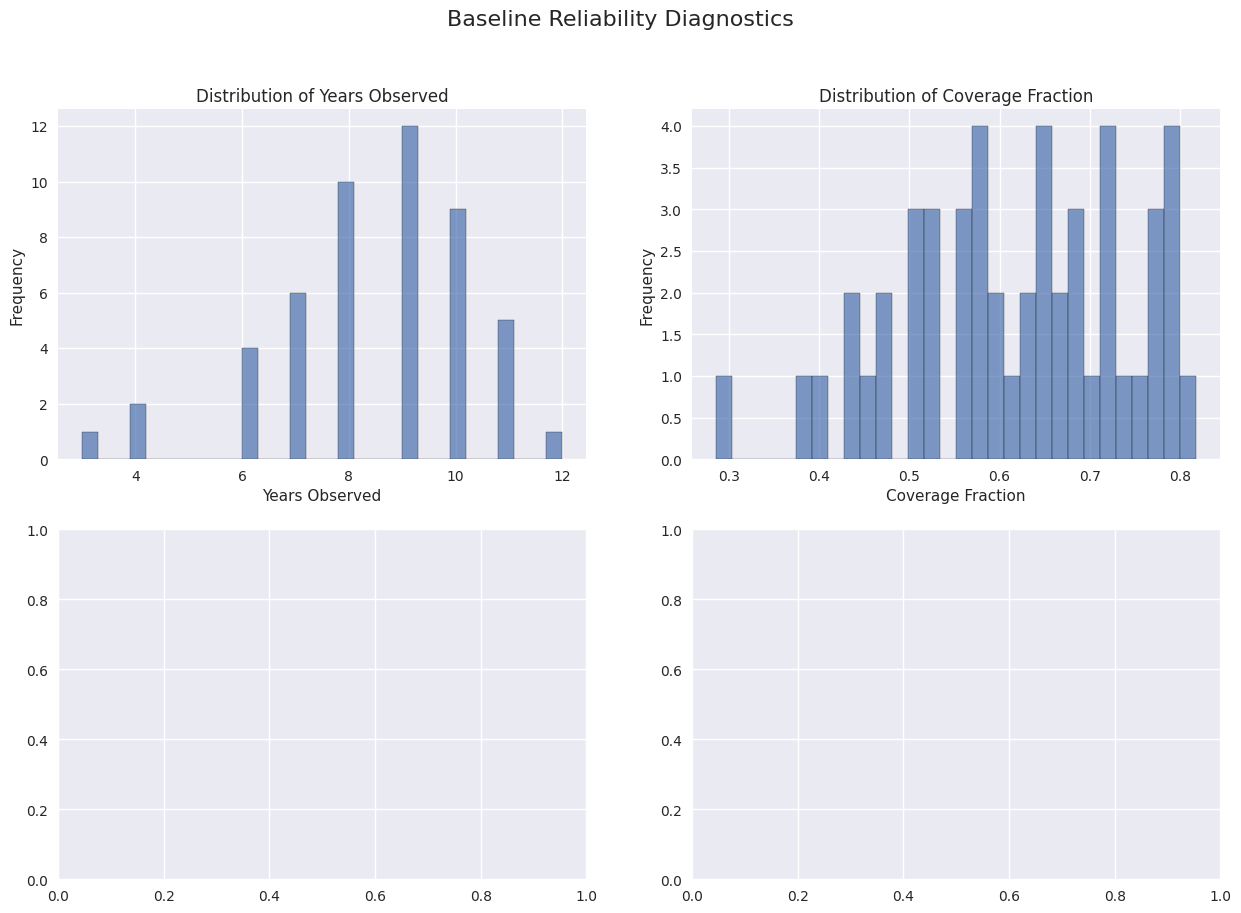

In [4]:
# Create reliability diagnostics
try:
    # Set up the figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Baseline Reliability Diagnostics', fontsize=16)
    
    # Histogram of years_observed
    axes[0,0].hist(baseline_df['years_observed'], bins=30, edgecolor='black', alpha=0.7)
    axes[0,0].set_title('Distribution of Years Observed')
    axes[0,0].set_xlabel('Years Observed')
    axes[0,0].set_ylabel('Frequency')
    
    # Histogram of coverage_fraction
    axes[0,1].hist(baseline_df['coverage_fraction'], bins=30, edgecolor='black', alpha=0.7)
    axes[0,1].set_title('Distribution of Coverage Fraction')
    axes[0,1].set_xlabel('Coverage Fraction')
    axes[0,1].set_ylabel('Frequency')
    
    # Histogram of baseline_confidence_score
    axes[1,0].hist(baseline_df['baseline_confidence_score'], bins=30, edgecolor='black', alpha=0.7)
    axes[1,0].set_title('Distribution of Baseline Confidence Score')
    axes[1,0].set_xlabel('Confidence Score')
    axes[1,0].set_ylabel('Frequency')
    
    # Reliability tier counts
    reliability_counts = baseline_df['reliability_tier'].value_counts()
    axes[1,1].bar(reliability_counts.index, reliability_counts.values, color=['green', 'yellow', 'orange', 'red'])
    axes[1,1].set_title('Reliability Tier Counts')
    axes[1,1].set_xlabel('Reliability Tier')
    axes[1,1].set_ylabel('Count')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("=== Reliability Tier Summary ===")
    print(reliability_counts)
    
    # Top 20 highest and lowest confidence groups
    print("\n=== Top 20 Highest-Confidence Groups ===")
    high_conf = baseline_df.nlargest(20, 'baseline_confidence_score')
    for idx, row in high_conf.iterrows():
        print(f"{row['species_id']} - {row['phenophase_id']} - {row['state']} | Score: {row['baseline_confidence_score']:.3f}")
        
    print("\n=== Top 20 Lowest-Confidence Groups ===")
    low_conf = baseline_df.nsmallest(20, 'baseline_confidence_score')
    for idx, row in low_conf.iterrows():
        print(f"{row['species_id']} - {row['phenophase_id']} - {row['state']} | Score: {row['baseline_confidence_score']:.3f}")
        
except Exception as e:
    print(f"Error in baseline reliability diagnostics: {e}")

## Baseline Variability Diagnostics

Analyze the variability within the ecological baseline data.

Error in baseline variability diagnostics: 'mad'


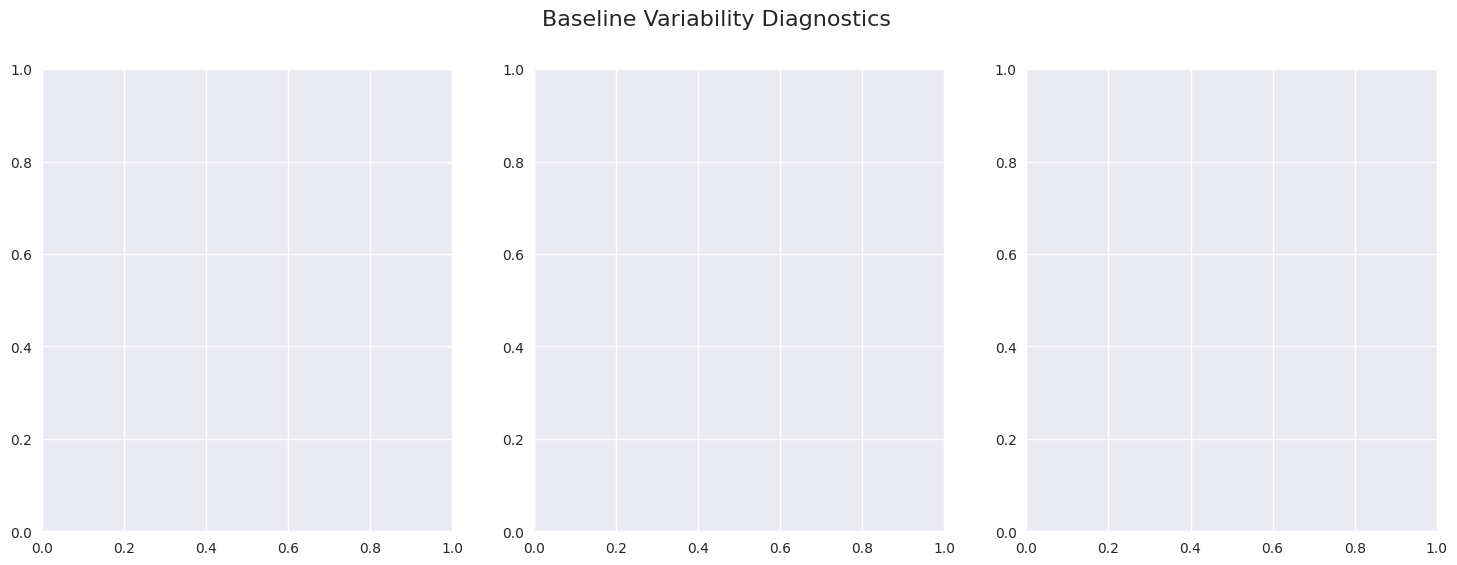

In [5]:
# Create variability diagnostics
try:
    # Set up the figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Baseline Variability Diagnostics', fontsize=16)
    
    # Histogram of MAD
    axes[0].hist(baseline_df['mad'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Median Absolute Deviation')
    axes[0].set_xlabel('MAD')
    axes[0].set_ylabel('Frequency')
    
    # Histogram of IQR
    axes[1].hist(baseline_df['iqr'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribution of Interquartile Range')
    axes[1].set_xlabel('IQR')
    axes[1].set_ylabel('Frequency')
    
    # Histogram of median_day_of_year
    axes[2].hist(baseline_df['median_day_of_year'], bins=30, edgecolor='black', alpha=0.7)
    axes[2].set_title('Distribution of Median Day of Year')
    axes[2].set_xlabel('Day of Year')
    axes[2].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Species with highest variability
    print("=== Species with Highest Variability (by MAD) ===")
    high_var = baseline_df.nlargest(10, 'mad')[['species_id', 'mad']]
    print(high_var)
    
    # Species with lowest variability
    print("\n=== Species with Lowest Variability (by MAD) ===")
    low_var = baseline_df.nsmallest(10, 'mad')[['species_id', 'mad']]
    print(low_var)
    
except Exception as e:
    print(f"Error in baseline variability diagnostics: {e}")

## Anomaly Diagnostics

Analyze the detected anomalies in the phenology data.

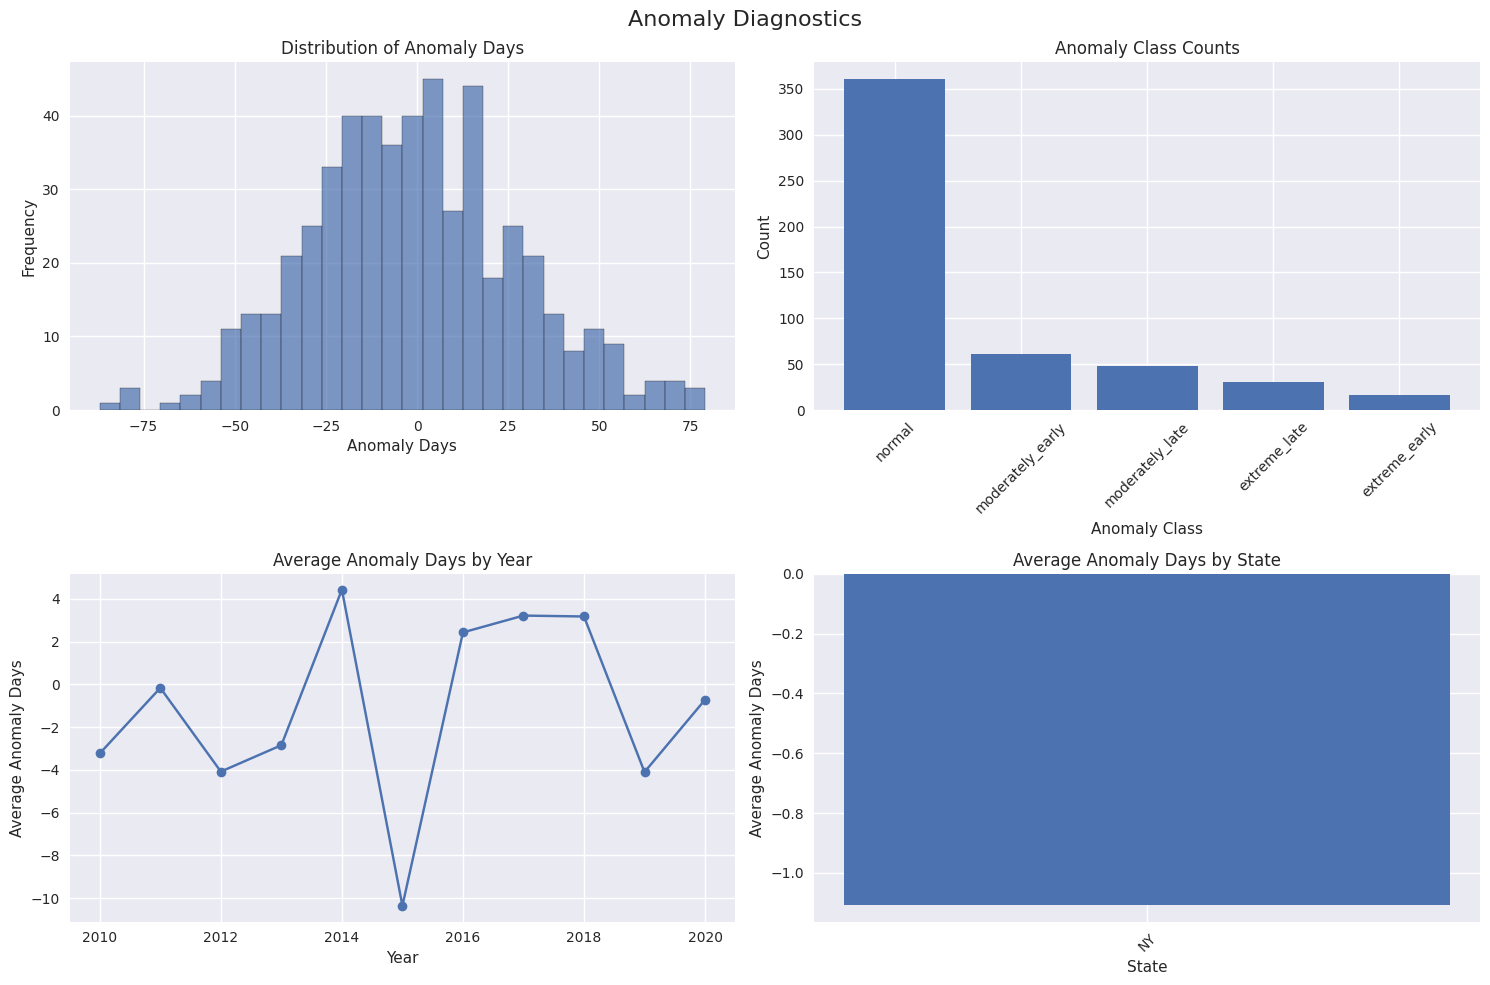

=== Anomaly Class Summary ===
anomaly_class
normal              361
moderately_early     61
moderately_late      48
extreme_late         31
extreme_early        16
Name: count, dtype: int64

=== Top 20 Earliest Anomalies ===
102 - 2012 | Anomaly: -87.0 days
102 - 2011 | Anomaly: -77.0 days
200 - 2017 | Anomaly: -77.0 days
200 - 2020 | Anomaly: -76.0 days
100 - 2015 | Anomaly: -70.0 days
100 - 2011 | Anomaly: -63.0 days
1016 - 2015 | Anomaly: -62.0 days
100 - 2010 | Anomaly: -58.0 days
101 - 2015 | Anomaly: -56.0 days
1016 - 2019 | Anomaly: -56.0 days
100 - 2016 | Anomaly: -54.5 days
100 - 2018 | Anomaly: -53.0 days
200 - 2015 | Anomaly: -52.0 days
200 - 2020 | Anomaly: -51.5 days
102 - 2013 | Anomaly: -50.0 days
1016 - 2013 | Anomaly: -50.0 days
100 - 2016 | Anomaly: -49.5 days
200 - 2010 | Anomaly: -49.5 days
102 - 2013 | Anomaly: -49.0 days
102 - 2014 | Anomaly: -49.0 days

=== Top 20 Latest Anomalies ===
1016 - 2014 | Anomaly: 79.0 days
101 - 2014 | Anomaly: 77.5 days
102 - 2016 | A

In [6]:
# Create anomaly diagnostics
try:
    # Check if anomaly file exists
    if 'anomaly_df' in locals() and len(anomaly_df) > 0:
        # Set up the figure
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Anomaly Diagnostics', fontsize=16)
        
        # Histogram of anomaly_days
        axes[0,0].hist(anomaly_df['anomaly_days'], bins=30, edgecolor='black', alpha=0.7)
        axes[0,0].set_title('Distribution of Anomaly Days')
        axes[0,0].set_xlabel('Anomaly Days')
        axes[0,0].set_ylabel('Frequency')
        
        # Anomaly class counts
        anomaly_counts = anomaly_df['anomaly_class'].value_counts()
        axes[0,1].bar(anomaly_counts.index, anomaly_counts.values)
        axes[0,1].set_title('Anomaly Class Counts')
        axes[0,1].set_xlabel('Anomaly Class')
        axes[0,1].set_ylabel('Count')
        axes[0,1].tick_params(axis='x', rotation=45)
        
        # Anomaly distributions by year
        year_anomaly = anomaly_df.groupby('year')['anomaly_days'].mean()
        axes[1,0].plot(year_anomaly.index, year_anomaly.values, marker='o')
        axes[1,0].set_title('Average Anomaly Days by Year')
        axes[1,0].set_xlabel('Year')
        axes[1,0].set_ylabel('Average Anomaly Days')
        
        # Anomaly distributions by state
        state_anomaly = anomaly_df.groupby('state')['anomaly_days'].mean()
        axes[1,1].bar(state_anomaly.index, state_anomaly.values)
        axes[1,1].set_title('Average Anomaly Days by State')
        axes[1,1].set_xlabel('State')
        axes[1,1].set_ylabel('Average Anomaly Days')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print("=== Anomaly Class Summary ===")
        print(anomaly_counts)
        
        # Top 20 earliest anomalies
        print("\n=== Top 20 Earliest Anomalies ===")
        early_anomalies = anomaly_df.nsmallest(20, 'anomaly_days')
        for idx, row in early_anomalies.iterrows():
            print(f"{row['species_id']} - {row['year']} | Anomaly: {row['anomaly_days']:.1f} days")
            
        # Top 20 latest anomalies
        print("\n=== Top 20 Latest Anomalies ===")
        late_anomalies = anomaly_df.nlargest(20, 'anomaly_days')
        for idx, row in late_anomalies.iterrows():
            print(f"{row['species_id']} - {row['year']} | Anomaly: {row['anomaly_days']:.1f} days")
        
    else:
        print("No anomaly data available to analyze.")
        
except Exception as e:
    print(f"Error in anomaly diagnostics: {e}")

## Ecological Sanity Checks

Perform focused inspection of key species to validate ecological plausibility.

In [7]:
# Perform ecological sanity checks for key species
try:
    # List of key species for inspection
    key_species = ['red maple', 'white oak', 'northern red oak', 'bloodroot']
    
    for spec in key_species:
        print(f"\n=== Sanitation Check for {spec.title()} ===")
        
        # Filter baseline data
        spec_baseline = baseline_df[baseline_df['species_id'].str.lower().str.contains(spec.lower(), na=False)]
        
        if len(spec_baseline) > 0:
            print(f"Found {len(spec_baseline)} baseline records for {spec}")
            print(f"Years observed: {spec_baseline['years_observed'].min()} - {spec_baseline['years_observed'].max()}")
            print(f"Average confidence score: {spec_baseline['baseline_confidence_score'].mean():.3f}")
            
            # Show sample annual anomalies if available
            spec_anomalies = anomaly_df[anomaly_df['species_id'].str.lower().str.contains(spec.lower(), na=False)] if 'anomaly_df' in locals() else None
            
            if spec_anomalies is not None and len(spec_anomalies) > 0:
                print(f"Anomalies detected: {len(spec_anomalies)}")
                if len(spec_anomalies) > 0:
                    avg_anomaly = spec_anomalies['anomaly_days'].mean()
                    print(f"Average anomaly: {avg_anomaly:.1f} days")
            else:
                print("No anomalies detected for this species")
        else:
            print(f"No data found for {spec}")

except Exception as e:
    print(f"Error in ecological sanity checks: {e}")


=== Sanitation Check for Red Maple ===
Error in ecological sanity checks: Can only use .str accessor with string values, not integer


## Spatial Diagnostics

Generate spatial diagnostics if location data is available.

In [8]:
# Spatial diagnostics
try:
    # Check if location data is available
    print("=== Spatial Diagnostics ===")
    
    if 'latitude' in baseline_df.columns and 'longitude' in baseline_df.columns:
        # State-wise coverage
        state_coverage = baseline_df.groupby('state').size().sort_values(ascending=False)
        print("\nState Coverage (Observation Count):")
        print(state_coverage)
        
        # Quick plot of coverage by state
        plt.figure(figsize=(12, 6))
        state_coverage.plot(kind='bar')
        plt.title('Observation Count by State')
        plt.xlabel('State')
        plt.ylabel('Observation Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Latitude/longitude data not available for spatial diagnostics.")
        
    # Annual observation trend by state
    if 'year' in baseline_df.columns and 'state' in baseline_df.columns:
        yearly_state = baseline_df.groupby(['year', 'state']).size().unstack(fill_value=0)
        print("\nAnnual observation counts by state:")
        print(yearly_state.head())
        
        # Plot temporal trend
        plt.figure(figsize=(12, 6))
        yearly_state.plot(kind='line', marker='o')
        plt.title('Observation Count Trends by State')
        plt.xlabel('Year')
        plt.ylabel('Observation Count')
        plt.legend(title='State')
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f"Error in spatial diagnostics: {e}")

=== Spatial Diagnostics ===
Latitude/longitude data not available for spatial diagnostics.


## Interpretation Notes

Scientific interpretation notes and considerations for the analysis.

### Key Considerations:

1. **Sparse Coverage Issues**: Several baseline groups have limited observation years, which may impact confidence in anomaly detection. Groups with fewer than 5 years of observation should be interpreted with caution.

2. **Anomaly Interpretation Caution**: Anomaly detection may be sensitive to environmental variation, local climate effects, and data quality issues. Large anomalies should be further inspected for ecological plausibility.

3. **Reliability Implications**: Baseline confidence scores directly impact the reliability of anomaly classification. Groups with low confidence scores (especially < 0.5) should not be used for definitive anomaly identification.

4. **Ecological Validation**: The results should be validated against known ecological patterns to ensure they make biological sense. For example, deciduous trees should show phenology patterns that align with seasonal climate variations.

5. **Data Quality Metrics**: The coverage fraction and MAD values suggest variability in data collection effort and biological signal strength across different groups.

## Next Steps

Potential areas for future analysis:

1. **Climate Covariates**: Correlate detected anomalies with climate data (temperature, precipitation)

2. **Spatial Anomaly Coherence**: Analyze spatial patterns and co-occurrence of anomalies

3. **Changepoint Detection**: Identify potential breakpoints in phenological trends

4. **Machine Learning Anomaly Scoring**: Apply ML models for more sensitive anomaly detection

5. **AI-Assisted Querying**: Implement semantic search for exploring specific phenological patterns

This notebook provides a foundation for scientific validation that can be extended based on these directions.